<div style="text-align: center;">
    <h1 style="font-size: 64px; 
               font-weight: 800;
               color: #1f0d4f;
               letter-spacing: 2px;
               margin: 40px 0;">
        LISTA 3
    </h1>
</div>

# Importy


In [1]:
import ctypes
import timeit
import matplotlib.pyplot as plt
import numpy as np
import sys

# Ustawienie stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Zadanie 1 - Klasa DynamicArray

<head>
  <link rel="stylesheet"
        href="https://cdnjs.cloudflare.com/ajax/libs/highlight.js/10.0.3/styles/default.min.css">
  <script src="https://cdnjs.cloudflare.com/ajax/libs/highlight.js/10.0.3/highlight.min.js"></script>
  <script>hljs.initHighlightingOnLoad();</script>
</head>
<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Uzupełnij klasę DynamicArray z wykładu o poniższe metody:</p>
            <pre><code class="python">
insert(self,k,value)
remove(self, value)
expand(self, seq)
___str__(self)
            </code></pre>

</div>

In [2]:
class DynamicArray:
    def __init__(self):
        self._n = 0              # liczba elementów
        self._capacity = 1       # rozmiar tablicy
        self._A = self._make_array(self._capacity)

    def __len__(self):
        return self._n

    def __getitem__(self, k):
        if not 0 <= k < self._n:
            raise IndexError('Index out of bounds')
        return self._A[k]

    def __setitem__(self, k, value):
        if not 0 <= k < self._n:
            raise IndexError('Index out of bounds')
        self._A[k] = value

    def append(self, obj):
        if self._n == self._capacity:
            self._resize(2 * self._capacity)
        self._A[self._n] = obj
        self._n += 1

    def _resize(self, c):
        B = self._make_array(c)
        for k in range(self._n):
            B[k] = self._A[k]
        self._A = B
        self._capacity = c

    def _make_array(self, c):
        return (c * ctypes.py_object)()

    def insert(self, k, value):
        if not 0 <= k <= self._n:
            raise IndexError("Index out of bounds")

        if self._n == self._capacity:
            self._resize(2 * self._capacity)

        # Przesuwanie elementów w prawo
        for i in range(self._n, k, -1):
            self._A[i] = self._A[i-1]

        self._A[k] = value
        self._n += 1

    def remove(self, value):
        """Usuwa pierwsze wystąpienie wartości."""
        for i in range(self._n):
            if self._A[i] == value:
                # Przesuwanie elementów w lewo, by zapełnić lukę
                for j in range(i, self._n - 1):
                    self._A[j] = self._A[j + 1]
                
                self._A[self._n - 1] = None # Dla garbage collectora
                self._n -= 1
                
                # USPRAWNIENIE: Zmniejsz tablicę, jeśli jest za duża
                # Zmniejszamy o połowę, gdy wykorzystanie spadnie poniżej 1/4
                if 0 < self._n < self._capacity // 4:
                    self._resize(self._capacity // 2)
                return

        raise ValueError("value not found")

    def expand(self, seq):
        """Rozszerza tablice o seq"""
        k = len(seq)
        if self._n + k > self._capacity:
            self._resize(max(self._capacity * 2, self._n + k))
            
        for item in seq:
            self._A[self._n] = item
            self._n += 1

    def __str__(self):
        return "[" + ", ".join(str(self._A[i]) for i in range(self._n)) + "]"
    
    def __iter__(self):
        """Umożliwia iterację: for x in arr: ..."""
        for i in range(self._n):
            yield self._A[i]

# Weryfikacja algorytmu

In [3]:
def test_algorithm():  
    # 1. Inicjalizacja
    da = DynamicArray()
    assert len(da) == 0, "Błąd: Nowa tablica powinna mieć długość 0"
    assert str(da) == "[]", "Błąd: Pusta tablica powinna wyglądać jak []"
    
    # 2. Test metody expand
    seq = [10, 20, 30]
    da.expand(seq)
    assert len(da) == 3, "Błąd: Długość po expand powinna wynosić 3"
    assert str(da) == "[10, 20, 30]", f"Błąd stringa: oczekiwano [10, 20, 30], otrzymano {str(da)}"
    assert da[0] == 10 and da[2] == 30, "Błąd: Elementy nie zgadzają się po expand"

    # 3. Test metody insert
    # Wstawianie na początek
    da.insert(0, 5)  # [5, 10, 20, 30]
    assert da[0] == 5, "Błąd: Insert na index 0 nie zadziałał"
    assert len(da) == 4, "Błąd: Zła długość po insert"
    
    # Wstawianie w środek
    da.insert(2, 15) # [5, 10, 15, 20, 30]
    assert da[2] == 15, "Błąd: Insert w środku nie zadziałał"
    assert str(da) == "[5, 10, 15, 20, 30]", "Błąd: Kolejność po insert jest zła"

    # Wstawianie na koniec (index == n)
    da.insert(5, 35) # [5, 10, 15, 20, 30, 35]
    assert da[5] == 35, "Błąd: Insert na koniec nie zadziałał"

    # Test insert z błędem (zły index)
    try:
        da.insert(100, 99)
    except IndexError:
        pass # Oczekiwane zachowanie
    else:
        assert False, "Błąd: Insert powinien rzucić IndexError dla indeksu spoza zakresu"

    # 4. Test metody remove
    # Usuwanie elementu ze środka
    da.remove(15) # [5, 10, 20, 30, 35]
    assert len(da) == 5, "Błąd: Długość po remove jest zła"
    assert 15 not in [da[i] for i in range(len(da))], "Błąd: Element 15 nadal istnieje"
    assert str(da) == "[5, 10, 20, 30, 35]", "Błąd: Przesunięcie elementów po remove nie zadziałało"

    # Usuwanie pierwszego elementu
    da.remove(5) # [10, 20, 30, 35]
    assert da[0] == 10, "Błąd: Usuwanie głowy (index 0) nie zadziałało"

    # Test remove z błędem (element nie istnieje)
    try:
        da.remove(999)
    except ValueError:
        pass # Oczekiwane zachowanie
    else:
        assert False, "Błąd: Remove powinien rzucić ValueError dla nieistniejącego elementu"

    # 5. Test __str__ na koniec
    expected_str = "[10, 20, 30, 35]"
    assert str(da) == expected_str, f"Błąd __str__: oczekiwano {expected_str}, jest {str(da)}"

    print("Wszystkie testy zaliczone pomyślnie!")

if __name__ == "__main__":
    test_algorithm()

Wszystkie testy zaliczone pomyślnie!


# Zadanie 2 - Analiza eksperymentalna metody pop()

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Przeprowadź analizę ekperymentalną metody <i>pop()</i> w pythonie.</p>
</div>

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Teoria:</h3>
    <p style="margin-bottom: 10px;">Wiedząc, że listy w Pythonie implementowane są jako <strong>Dynamic Arrays</strong> (tablice dynamiczne), możemy wysnuć następujące hipotezy:</p>
    <ul style="margin-left: 20px; margin-bottom: 0; list-style-type: disc;">
        <li style="margin-bottom: 8px;">
            <strong>Hipoteza 1:</strong> Metoda <code>pop()</code> (usuwanie ostatniego elementu) nie wymaga przesuwania innych danych w pamięci.
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(1)}$</b>.</span>
        </li>
        <li style="margin-bottom: 8px;">
            <strong>Hipoteza 2:</strong> Metoda <code>pop(0)</code> (usuwanie pierwszego elementu) wymusza zmianę indeksów wszystkich pozostałych elementów (przesunięcie w lewo).
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(N)}$</b>.</span>
        </li>
        <li>
            <strong>Hipoteza 3:</strong> Metoda <code>pop(k)</code> (usuwanie ze środka) ma koszt proporcjonalny do liczby elementów znajdujących się "za" usuwanym indeksem.
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(N-k)}$</b>.</span>
        </li>
    </ul>
</div>

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Eksperyment 1: Zależność czasu od rozmiaru listy ($N$)</h3>
    <p>W tym etapie sprawdzimy, jak czas wykonania <code>pop()</code> oraz <code>pop(0)</code> zmienia się wraz z liniowym wzrostem liczby elementów w liście.</p>
    <p><strong>Metodologia:</strong></p>
    <ul style="margin-left: 20px; margin-bottom: 0;">
        <li>Dla rozmiarów $N$ od 10,000 do 200,000 wykonamy serię pomiarów.</li>
        <li>Oczekujemy, że <code>pop()</code> będzie linią płaską (stały czas).</li>
        <li>Oczekujemy, że <code>pop(0)</code> będzie funkcją liniową rosnącą.</li>
    </ul>
</div>

Przeprowadzanie pomiarów dla N=10000 do 200000...


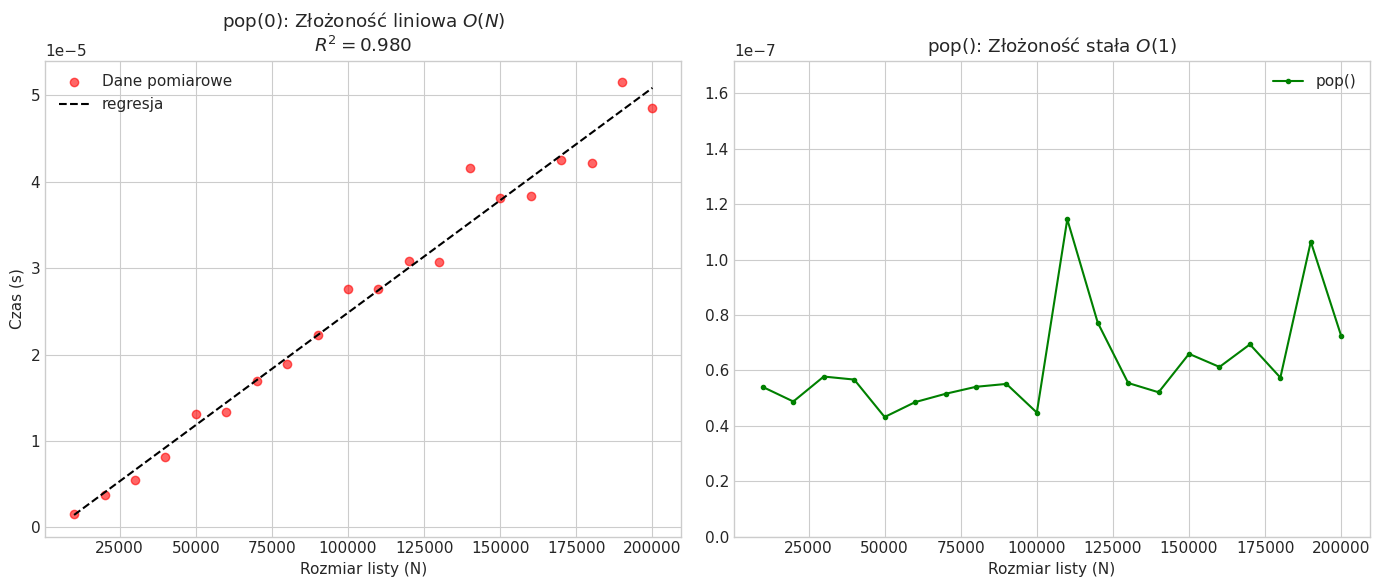

Współczynnik kierunkowy dla pop(0): 2.5998845703451714e-10
Współczynnik kierunkowy dla pop(): 1.4977613455244792e-13


In [4]:
def run_size_experiment(start_n=10000, end_n=200000, step=10000):
    sizes = np.arange(start_n, end_n + 1, step)
    times_pop_end = []
    times_pop_start = []
    
    print(f"Przeprowadzanie pomiarów dla N={start_n} do {end_n}...")
    
    for n in sizes:
        
        # Test pop()
        t_end = timeit.timeit("x.pop()", setup=f"x = list(range({n}))", number=100)
        times_pop_end.append(t_end / 100) # Czas na 1 operację
        
        # Test pop(0)
        t_start = timeit.timeit("x.pop(0)", setup=f"x = list(range({n}))", number=100)
        times_pop_start.append(t_start / 100)
        
    return sizes, np.array(times_pop_end), np.array(times_pop_start)

# Uruchomienie
sizes, times_end, times_start = run_size_experiment()

# Dopasowanie krzywych

# Dla pop(0) oczekujemy funkcji liniowej: y = ax + b
coeffs_start = np.polyfit(sizes, times_start, 1) # stopień 1 (liniowy)
poly_start = np.poly1d(coeffs_start)
r_squared_start = np.corrcoef(sizes, times_start)[0, 1]**2

# Dla pop() oczekujemy funkcji stałej
coeffs_end = np.polyfit(sizes, times_end, 1)
poly_end = np.poly1d(coeffs_end)

# Wykresiki
fig, (ax1, ax2) = plt.subplots(1, 2)

# Wykres 1: pop(0) z regresją
ax1.scatter(sizes, times_start, color='red', alpha=0.6, label='Dane pomiarowe')
ax1.plot(sizes, poly_start(sizes), 'k--', label=f'regresja')
ax1.set_title(f'pop(0): Złożoność liniowa $O(N)$\n$R^2 = {r_squared_start:.3f}$')
ax1.set_xlabel('Rozmiar listy (N)')
ax1.set_ylabel('Czas (s)')
ax1.legend()

# Wykres 2: pop()
ax2.plot(sizes, times_end, color='green', marker='.', linestyle='-', label='pop()')
ax2.set_title('pop(): Złożoność stała $O(1)$')
ax2.set_xlabel('Rozmiar listy (N)')
ax2.set_ylim(0, max(times_end) * 1.5) # Ustawienie y od 0
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Współczynnik kierunkowy dla pop(0): {coeffs_start[0]}")
print(f"Współczynnik kierunkowy dla pop(): {coeffs_end[0]}")

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Eksperyment 2: Zależność czasu od indeksu ($k$)</h3>
    <p>Skoro <code>pop(0)</code> przesuwa $N$ elementów, a <code>pop()</code> (czyli <code>pop(N)</code>) przesuwa 0 elementów, to czas wykonania powinien zależeć od tego, jak głęboko w liście usuwamy element.</p>
    <p style="margin-bottom: 0;">
        Ustalamy stały, duży rozmiar listy <strong>$N = 1,000,000$</strong> i badamy czas <code>pop(k)</code> dla różnych wartości $k$.<br>
        <span style="color: #dc2626;">Hipoteza:</span> Wykres powinien pokazać liniowy spadek czasu wraz ze zbliżaniem się do końca listy ($O(N-k)$).
    </p>
</div>

Badanie wpływu indeksu k dla stałego N=1000000...


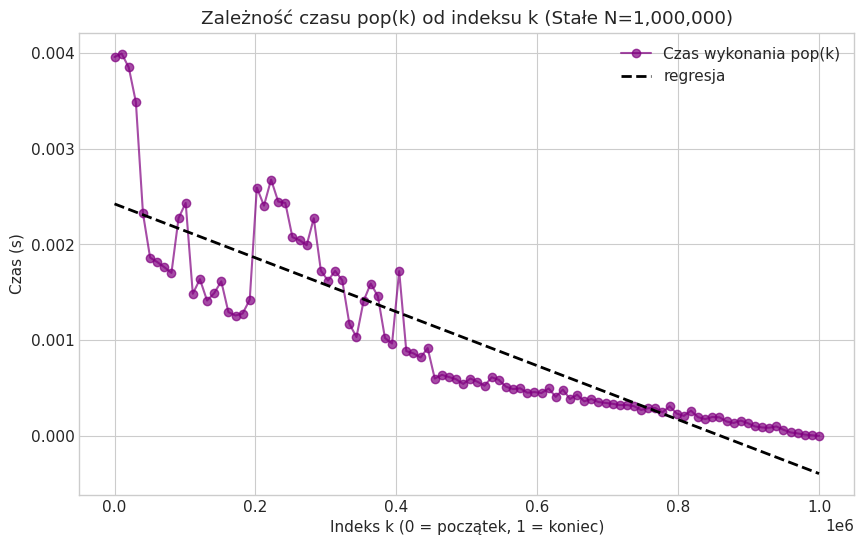

In [5]:
def run_index_experiment(fixed_n=1_000_000, num_points=100):
    indices = np.linspace(0, fixed_n - 100, num_points, dtype=int)
    times_k = []
    
    print(f"Badanie wpływu indeksu k dla stałego N={fixed_n}...")
    
    global test_list # global dla timeit
    
    for k in indices:
        # Tworzymy nową listę przed każdym pomiarem, aby warunki były identyczn       
        stmt = f"test_list.pop({k})"
        setup = f"global test_list; test_list = list(range({fixed_n}))"
        
        t = timeit.timeit(stmt, setup=setup, number=100) 
        times_k.append(t / 20)

    return indices, np.array(times_k)

indices, times_k = run_index_experiment()

# Wykresiki
plt.figure(figsize=(10, 6))
plt.plot(indices, times_k, 'o-', color='purple', alpha=0.7, label='Czas wykonania pop(k)')

# Teoretyczna regresja liniowa
z = np.polyfit(indices, times_k, 1)
p = np.poly1d(z)
plt.plot(indices, p(indices), "k--", linewidth=2, label=f'regresja')

plt.title(f'Zależność czasu pop(k) od indeksu k (Stałe N=1,000,000)')
plt.xlabel('Indeks k (0 = początek, 1 = koniec)')
plt.ylabel('Czas (s)')
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Wnioski końcowe</h3>
    <p>Na podstawie przeprowadzonych eksperymentów i analizy regresji:</p>  
    <ol style="margin-left: 20px;">
        <li style="margin-bottom: 10px;">
            <strong>Operacja <code>pop(0)</code> ($\mathcal{O}(N)$):</strong><br> 
            Wykres wykazuje zależność liniową. Potwierdza to, że usunięcie elementu z początku listy wiąże się z przesunięciem wszystkich pozostałych elementów w pamięci.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Operacja <code>pop()</code> ($\mathcal{O}(1)$):</strong><br> 
            Czas wykonania jest niezależny od rozmiaru listy. Wahania są pomijalne (szum systemowy).
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Operacja <code>pop(k)</code> ($\mathcal{O}{(N-k)}$):</strong><br> 
            Wykres pokazuje ujemne nachylenie liniowe. Im wyższy indeks (bliżej końca), tym operacja jest tańsza.
        </li>
    </ol>
</div>

# Zadanie 3 - Suma el. macierzy

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p>  Napisz funkcję liczącą sumę wszystkich elementów tablicy $n \times n$ reprezentowanej jako lista lista </p>
</div>

In [6]:
def sum_n_x_n(tab):
    sum_of_table = 0
    for row in tab:
        sum_of_table += sum(row)
    return sum_of_table

table = [[1,1,1],
         [1,1,1],
         [1,1,1]]
print(sum_n_x_n(table))

9


# Zadanie 4 - Metoda ```extend()``` vs wielokrotne wywołanie ```apend()```

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Zaprojektuj i wykonaj esperyment, który pozwoli porównać względną wydajność metody <code> extend() </code> oraz wielokrotnego wywołania metody <code> append() </code></p>
</div>

## Wstęp teoretyczny: Jak działają listy w Pythonie

W Pythonie lista to tak naprawdę **dynamiczna tablica** - czyli kawałek pamięci, który przechowuje wskaźniki do naszych obiektów. Najważniejsza rzecz, która wpływa na szybkość działania, to jak Python zarządza pamięcią, zwłaszcza gdy lista musi "urosnąć".

### Porównanie dwóch metod dodawania elementów

**1. Metoda `append()` w pętli:**

- **Jak to działa:** Każde wywołanie `append()` to osobna komenda dla Pythona. Za każdym razem Python musi "przeskoczyć" między swoim kodem a kodem w C.
- **Problem z pamięcią:**  Dodając $N$ elementów, Python nie wie z góry, ile miejsca będzie potrzebne. Gdy lista się zapełni, musi znaleźć nowy, większy kawałek pamięci i przekopiować tam wszystko od nowa.

To może się zdarzyć kilka razy podczas dodawania (około $\mathcal{O}{(\log N)}$ razy).

**2. Metoda `extend()`:**

- **Jak to działa:** To jedno wywołanie funkcji. Cała pętla, która dodaje elementy, dzieje się **wewnątrz kodu w C**, więc omijamy narzut związany z pętlą `for` w Pythonie.
- **Problem z pamięcią:** `extend()` jest sprytniejsze - najpierw sprawdza, ile elementów będzie dodawanych (jeśli to możliwe, np. gdy dodajesz inną listę). Dzięki temu może **od razu zarezerwować odpowiednią ilość pamięci** i skopiować wszystkie elementy za jednym zamachem, zamiast robić to kawałkami.

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Hipoteza badawcza</h3>
    <p>Zakłada się, że metoda <code>extend()</code> wykaże znacząco wyższą wydajność czasową w porównaniu do iteracyjnego stosowania metody <code>append()</code>.</p> 
    <p>Przewidywana przewaga wynika z dwóch czynników:</p>
    <ol style="margin-left: 20px;">
        <li style="margin-bottom: 10px;">
            <strong>Redukcja narzutu interpretera:</strong> Przeniesienie pętli iteracyjnej z poziomu kodu bajtowego Pythona do poziomu języka C.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Optymalizacja alokacji pamięci:</strong> Zminimalizowanie liczby operacji <code>realloc</code> dzięki znajomości rozmiaru dodawanych danych przed rozpoczęciem operacji kopiowania.
        </li>
    </ol>
</div>

ciekawy wątek: https://stackoverflow.com/questions/68636472/memory-allocation-when-casting-to-a-list-in-python

N (elementy)    | Append (s)      | Extend (s)      | Przyśpieszenie
------------------------------------------------------------
1000            | 0.000018          | 0.000002          | 9.56x
5000            | 0.000086          | 0.000011          | 7.85x
10000           | 0.000140          | 0.000030          | 4.75x
50000           | 0.000610          | 0.000153          | 3.98x
100000          | 0.001280          | 0.000289          | 4.42x
500000          | 0.008429          | 0.003089          | 2.73x
1000000         | 0.016928          | 0.009066          | 1.87x
10000000        | 0.182445          | 0.073466          | 2.48x


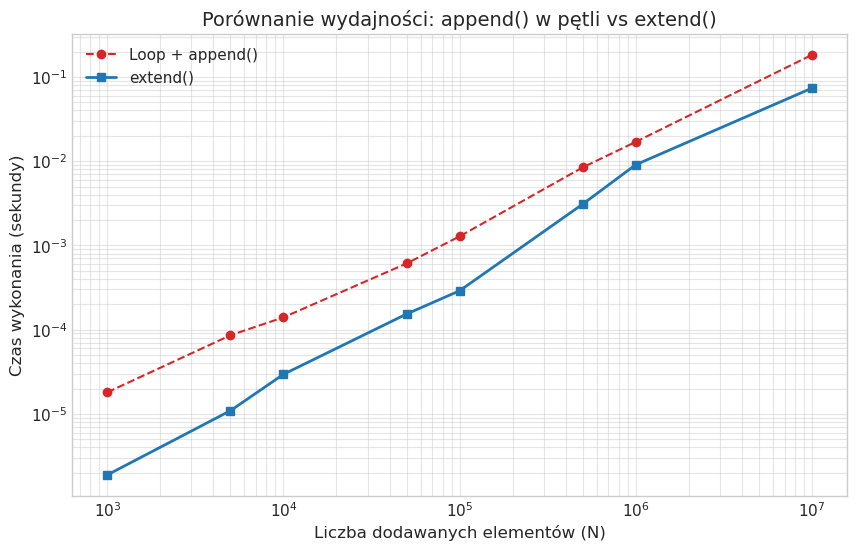

In [7]:
import timeit
import matplotlib.pyplot as plt
import numpy as np

input_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 10000000]
results_append = []
results_extend = []

def get_number_of_runs(n):
    return 1000 if n < 10000 else 100 if n < 100000 else 10

def test_append_loop(base_list, data_to_add):
    l = list(base_list) 
    for item in data_to_add:
        l.append(item)

def test_extend(base_list, data_to_add):
    l = list(base_list)
    l.extend(data_to_add)

# Wykonanie pomiarów
print(f"{'N (elementy)':<15} | {'Append (s)':<15} | {'Extend (s)':<15} | {'Przyśpieszenie':<10}")
print("-" * 60)

for n in input_sizes:
    data = list(range(n))
    base = [] # Pusta lista bazowa
    
    runs = get_number_of_runs(n)
    
    setup_code = f"data = list(range({n})); base = []"
    
    # Pomiar pętli z append
    stmt_append = """
l = []
for item in data:
    l.append(item)
"""
    t_append = timeit.timeit(stmt_append, setup=setup_code, number=runs) / runs
    results_append.append(t_append)
    
    # Pomiar extend
    stmt_extend = """
l = []
l.extend(data)
"""
    t_extend = timeit.timeit(stmt_extend, setup=setup_code, number=runs) / runs
    results_extend.append(t_extend)
    
    # Obliczenie przyspieszenia
    speedup = t_append / t_extend
    
    print(f"{n:<15} | {t_append:.6f}          | {t_extend:.6f}          | {speedup:.2f}x")

# Wizualizacja wyników
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, results_append, marker='o', label='Loop + append()', color='#d62728', linestyle='--')
plt.plot(input_sizes, results_extend, marker='s', label='extend()', color='#1f77b4', linewidth=2)

plt.title('Porównanie wydajności: append() w pętli vs extend()', fontsize=14)
plt.xlabel('Liczba dodawanych elementów (N)', fontsize=12)
plt.ylabel('Czas wykonania (sekundy)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.xscale('log') # Skala logarytmiczna na osi X dla lepszej czytelności
plt.yscale('log') # Skala logarytmiczna na osi Y, ponieważ różnice są rzędu wielkości

plt.show()

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;"> 
    <h3 style="margin-top: 0; color: #1e40af;">Wnioski końcowe</h3> 
    <p>Na podstawie przeprowadzonych eksperymentów:</p> 
    <ol style="margin-left: 20px;"> <li style="margin-bottom: 10px;"> <strong>Wydajność względna:</strong>

Metoda <code>extend()</code> jest szybsza od wielokrotnego wywołania <code>append()</code>. Eksperyment wykazuje przyspieszenie rzędu <strong>2x do 10x</strong> na korzyść <code>extend()</code>. </li> <li style="margin-bottom: 10px;"> <strong>Złożoność obliczeniowa:</strong>

Obie metody charakteryzują się złożonością liniową $\mathcal{O}(k)$, gdzie k to liczba dodawanych elementów. Jednakże stała ukryta w notacji Big-O jest znacznie mniejsza dla <code>extend()</code> ze względu na przeniesienie iteracji do poziomu języka C. </li> <li style="margin-bottom: 10px;"> <strong>Alokacja pamięci:</strong>
Kluczową przewagą <code>extend()</code> jest zdolność do jednorazowej realokacji pamięci (gdy długość danych wejściowych jest znana), co eliminuje kosztowne, pośrednie kopiowanie tablicy, które występuje przy sukcesywnym używaniu <code>append()</code>. </li> </ol> </div>

# Zadanie 5

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Zmodyfikuj implementację kolejki z wykładu, tak aby zwalniała ona pamięć w sytuacji, gdy liczba elementów w niej jest bardzo mała</p>
</div>

In [8]:
class Empty(Exception):
    pass

class Queue:
    DEFAULT_CAPACITY = 10
    
    def __init__(self):
        self._data = [None]*Queue.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0
        
    def __len__(self):
        return self._size
    
    def is_empty(self):
        return self._size == 0
    
    def first(self):
        if self.is_empty():
            raise Empty('Queue is empty')
        return self._data[self._front]
    
    def dequeue(self):
        if self.is_empty():
            raise Empty('Queue is empty')
        value = self._data[self._front]
        self._data[self._front] = None
        self._front = (self._front+1)%len(self._data)
        self._size -= 1

        # Wprowadzona zmiana: jeśli elementów jest mniej niz 1/4 dlugosci kolejki to zmniejszamy o polowe 
        if 0 < self._size < len(self._data)//4 and len(self._data) > Queue.DEFAULT_CAPACITY:
            new_capacity = max(len(self._data)//2, Queue.DEFAULT_CAPACITY)
            self._resize(new_capacity)

        return value
    
    def enqueue(self,e):
        if self._size == len(self._data):
            self._resize(2*len(self._data))
        avail = (self._front + self._size)%len(self._data)
        self._data[avail] = e
        self._size += 1
        
    def _resize(self,cap):
        old = self._data
        self._data = [None]*cap
        walk = self._front
        for k in range(self._size): #only existing elements
            self._data[k] = old[walk]
            walk = (1 + walk)%len(old)
        self._front = 0  


q = Queue()
for i in range(50):
    q.enqueue(i)

for i in range(45):
    q.dequeue()
    print(f"Size: {len(q)}, Capacity: {len(q._data)}")


Size: 49, Capacity: 80
Size: 48, Capacity: 80
Size: 47, Capacity: 80
Size: 46, Capacity: 80
Size: 45, Capacity: 80
Size: 44, Capacity: 80
Size: 43, Capacity: 80
Size: 42, Capacity: 80
Size: 41, Capacity: 80
Size: 40, Capacity: 80
Size: 39, Capacity: 80
Size: 38, Capacity: 80
Size: 37, Capacity: 80
Size: 36, Capacity: 80
Size: 35, Capacity: 80
Size: 34, Capacity: 80
Size: 33, Capacity: 80
Size: 32, Capacity: 80
Size: 31, Capacity: 80
Size: 30, Capacity: 80
Size: 29, Capacity: 80
Size: 28, Capacity: 80
Size: 27, Capacity: 80
Size: 26, Capacity: 80
Size: 25, Capacity: 80
Size: 24, Capacity: 80
Size: 23, Capacity: 80
Size: 22, Capacity: 80
Size: 21, Capacity: 80
Size: 20, Capacity: 80
Size: 19, Capacity: 40
Size: 18, Capacity: 40
Size: 17, Capacity: 40
Size: 16, Capacity: 40
Size: 15, Capacity: 40
Size: 14, Capacity: 40
Size: 13, Capacity: 40
Size: 12, Capacity: 40
Size: 11, Capacity: 40
Size: 10, Capacity: 40
Size: 9, Capacity: 20
Size: 8, Capacity: 20
Size: 7, Capacity: 20
Size: 6, Capac

# Zadanie 6 - Kolejka dwustronna

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Zaimplementuj kolejkę dwustronną </p>
</div>

In [9]:
class Deque:
    """Kolejka dwukierunkowa"""
    DEFAULT_CAPACITY = 10
    
    def __init__(self):
        self._data = [None] * Deque.DEFAULT_CAPACITY
        self._size = 0
        self._front = 0
        
    def __len__(self):
        return self._size
    
    def is_empty(self):
        return self._size == 0
    
    def first(self):
        """Zwraca element z przodu kolejki bez usuwania."""
        if self.is_empty():
            raise Empty('Deque is empty')
        return self._data[self._front]
    
    def last(self):
        """Zwraca element z tyłu kolejki bez usuwania."""
        if self.is_empty():
            raise Empty('Deque is empty')
        back = (self._front + self._size - 1) % len(self._data)
        return self._data[back]
    
    def add_first(self, e):
        """Dodaje element na początku kolejki."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))
        self._front = (self._front - 1) % len(self._data)
        self._data[self._front] = e
        self._size += 1
    
    def add_last(self, e):
        """Dodaje element na końcu kolejki."""
        if self._size == len(self._data):
            self._resize(2 * len(self._data))
        avail = (self._front + self._size) % len(self._data)
        self._data[avail] = e
        self._size += 1
    
    def delete_first(self):
        """Usuwa i zwraca element z przodu kolejki."""
        if self.is_empty():
            raise Empty('Deque is empty')
        value = self._data[self._front]
        self._data[self._front] = None
        self._front = (self._front + 1) % len(self._data)
        self._size -= 1
        # Zmniejszanie tablicy gdy jest mało elementów
        if 0 < self._size < len(self._data) // 4 and len(self._data) > Deque.DEFAULT_CAPACITY:
            new_capacity = max(len(self._data) // 2, Deque.DEFAULT_CAPACITY)
            self._resize(new_capacity)
        return value
    
    def delete_last(self):
        """Usuwa i zwraca element z tyłu kolejki."""
        if self.is_empty():
            raise Empty('Deque is empty')
        back = (self._front + self._size - 1) % len(self._data)
        value = self._data[back]
        self._data[back] = None
        self._size -= 1
        # Zmniejszanie tablicy gdy jest mało elementów
        if 0 < self._size < len(self._data) // 4 and len(self._data) > Deque.DEFAULT_CAPACITY:
            new_capacity = max(len(self._data) // 2, Deque.DEFAULT_CAPACITY)
            self._resize(new_capacity)
        return value
    
    def _resize(self, cap):
        """Zmienia rozmiar wewnętrznej tablicy."""
        old = self._data
        self._data = [None] * cap
        walk = self._front
        for k in range(self._size):
            self._data[k] = old[walk]
            walk = (1 + walk) % len(old)
        self._front = 0

In [10]:
dq = Deque()
# Dodawanie elementów
dq.add_last(5)
dq.add_first(3)
dq.add_first(1)
dq.add_last(7)
    
print(f"Rozmiar: {len(dq)}")  # 4
print(f"Pierwszy: {dq.first()}")  # 1
print(f"Ostatni: {dq.last()}")  # 7
    
# Usuwanie elementów
print(f"Usunięto z przodu: {dq.delete_first()}")  # 1
print(f"Usunięto z tyłu: {dq.delete_last()}")  # 7
    
print(f"Rozmiar po usunięciu: {len(dq)}")  # 2
print(f"Pierwszy: {dq.first()}")  # 3
print(f"Ostatni: {dq.last()}")  # 5

Rozmiar: 4
Pierwszy: 1
Ostatni: 7
Usunięto z przodu: 1
Usunięto z tyłu: 7
Rozmiar po usunięciu: 2
Pierwszy: 3
Ostatni: 5


# Zadanie 7 - Sprawdzanie składni HTML'a


<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Napisz algorytm, który sprawdzi poprawność składni dokument HTML pod kątem brakujących znaczników zamykających.</p>
</div>

In [11]:
def validate_html(html):
    stack = []
    i = 0
    
    # Tagi samozamykające się
    self_closing = {'br', 'hr', 'img', 'input', 'meta', 'link', 'area', 'base', 'col', 'embed', 'source', 'track', 'wbr'}
    
    while i < len(html):
        if html[i] == '<':
            # Znajdź koniec tagu
            j = i + 1
            while j < len(html) and html[j] != '>':
                j += 1
            
            if j >= len(html):
                return False  # Brak zamykającego >
            
            tag_content = html[i+1:j].strip()
            
            # Ignoruj komentarze i DOCTYPE
            if tag_content.startswith('!') or tag_content.startswith('?'):
                i = j + 1
                continue
            
            # Tag zamykający
            if tag_content.startswith('/'):
                tag_name = tag_content[1:].split()[0].lower()
                if not stack or stack[-1] != tag_name:
                    return False  # Brak pasującego tagu otwierającego
                stack.pop()
            
            # Tag otwierający
            else:
                tag_name = tag_content.split()[0].split('/')[0].lower()
                
                # Ignoruj tagi samozamykające się
                if tag_name not in self_closing and not tag_content.endswith('/'):
                    stack.append(tag_name)
            
            i = j + 1
        else:
            i += 1
    
    # Jeśli stos jest pusty, wszystkie tagi są poprawnie zamknięte
    return len(stack) == 0

In [12]:
validate_html("""
<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Teoria:</h3>
    <p style="margin-bottom: 10px;">Wiedząc, że listy w Pythonie implementowane są jako <strong>Dynamic Arrays</strong> (tablice dynamiczne), możemy wysnuć następujące hipotezy:</p>
    <ul style="margin-left: 20px; margin-bottom: 0; list-style-type: disc;">
        <li style="margin-bottom: 8px;">
            <strong>Hipoteza 1:</strong> Metoda <code>pop()</code> (usuwanie ostatniego elementu) nie wymaga przesuwania innych danych w pamięci.
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(1)}$</b>.</span>
        </li>
        <li style="margin-bottom: 8px;">
            <strong>Hipoteza 2:</strong> Metoda <code>pop(0)</code> (usuwanie pierwszego elementu) wymusza zmianę indeksów wszystkich pozostałych elementów (przesunięcie w lewo).
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(N)}$</b>.</span>
        </li>
        <li>
            <strong>Hipoteza 3:</strong> Metoda <code>pop(k)</code> (usuwanie ze środka) ma koszt proporcjonalny do liczby elementów znajdujących się "za" usuwanym indeksem.
            <br><span style="color: #4b5563;">&rarr; Oczekiwana złożoność: <b>$\mathcal{O}{(N-k)}$</b>.</span>
        </li>
    </ul>
</div>
""")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_173981/1270505162.py:1: SyntaxWarning: invalid escape sequence '\m'
  validate_html("""


True

In [13]:
validate_html(" <div> Pies je kota </</div>>")

False

# Zadanie 8 - Permutacje

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Zaproponuj nierekurencyjny algorytm wypisujący wszystkie permutacje liczb od 1 do n wykorzystując do tego stos.</p>
</div>

In [14]:
def permutations_with_stack(n):
    if n <= 0:
        return []
    
    permutations = []
    elements = list(range(1, n + 1))
    
    # Stos przechowuje pary: (częściowa_permutacja, pozostałe_elementy)
    stack = [([], elements)]
    print(stack)
    
    while stack:
        current_perm, remaining = stack.pop()
        
        # Jeśli nie ma już elementów do dodania to prłna permutacja
        if not remaining:
            permutations.append(current_perm)
            continue
        
        # Dla każdego pozostałego elementu - nowy stan
        for i in range(len(remaining)):
            # Wybierz i-ty element
            chosen = remaining[i]
            # Nowa permutacja = aktualna + wybrany element
            new_perm = current_perm + [chosen]
            # Pozostałe elementy = wszystkie oprócz wybranego
            new_remaining = remaining[:i] + remaining[i+1:]
            # Dodaj nowy stan na stos
            print(new_perm)
            stack.append((new_perm, new_remaining))
    
    return permutations


def print_permutations(n):
    perms = permutations_with_stack(n)
    print(f"Wszystkie permutacje liczb od 1 do {n}:")
    print(f"Liczba permutacji: {len(perms)}")
    
    for i, perm in enumerate(perms, 1):
        print(f"{i:3d}. {perm}")
        
def visualize_algorithm(n):
    print(f"\n{'='*70}")
    print(f"WIZUALIZACJA DZIAŁANIA ALGORYTMU DLA n={n}")
    print(f"{'='*70}\n")
    
    elements = list(range(1, n + 1))
    stack = [([], elements)]
    step = 0
    permutations = []
    
    print(f"START: Stos = [([], {elements})]\n")
    
    while stack:
        step += 1
        current_perm, remaining = stack.pop()
        
        print(f"Krok {step}:")
        print(f" Pop ze stosu: permutacja={current_perm}, pozostałe={remaining}")
        
        if not remaining:
            permutations.append(current_perm)
            print(f"Znaleziono pełną permutację: {current_perm}")
        else:
            print(f"Generuję nowe stany dla pozostałych elementów {remaining}:")
            for i in range(len(remaining)):
                chosen = remaining[i]
                new_perm = current_perm + [chosen]
                new_remaining = remaining[:i] + remaining[i+1:]
                stack.append((new_perm, new_remaining))
                print(f"    Push: ({new_perm}, {new_remaining})")
        
        print(f"Rozmiar stosu: {len(stack)}\n")
    
    print(f"\nZNALEZIONE PERMUTACJE: {permutations}")
    print(f"Łącznie: {len(permutations)} permutacji")

In [15]:
visualize_algorithm(3)


WIZUALIZACJA DZIAŁANIA ALGORYTMU DLA n=3

START: Stos = [([], [1, 2, 3])]

Krok 1:
 Pop ze stosu: permutacja=[], pozostałe=[1, 2, 3]
Generuję nowe stany dla pozostałych elementów [1, 2, 3]:
    Push: ([1], [2, 3])
    Push: ([2], [1, 3])
    Push: ([3], [1, 2])
Rozmiar stosu: 3

Krok 2:
 Pop ze stosu: permutacja=[3], pozostałe=[1, 2]
Generuję nowe stany dla pozostałych elementów [1, 2]:
    Push: ([3, 1], [2])
    Push: ([3, 2], [1])
Rozmiar stosu: 4

Krok 3:
 Pop ze stosu: permutacja=[3, 2], pozostałe=[1]
Generuję nowe stany dla pozostałych elementów [1]:
    Push: ([3, 2, 1], [])
Rozmiar stosu: 4

Krok 4:
 Pop ze stosu: permutacja=[3, 2, 1], pozostałe=[]
Znaleziono pełną permutację: [3, 2, 1]
Rozmiar stosu: 3

Krok 5:
 Pop ze stosu: permutacja=[3, 1], pozostałe=[2]
Generuję nowe stany dla pozostałych elementów [2]:
    Push: ([3, 1, 2], [])
Rozmiar stosu: 3

Krok 6:
 Pop ze stosu: permutacja=[3, 1, 2], pozostałe=[]
Znaleziono pełną permutację: [3, 1, 2]
Rozmiar stosu: 2

Krok 7:
 Po

In [16]:
print_permutations(4)

[([], [1, 2, 3, 4])]
[1]
[2]
[3]
[4]
[4, 1]
[4, 2]
[4, 3]
[4, 3, 1]
[4, 3, 2]
[4, 3, 2, 1]
[4, 3, 1, 2]
[4, 2, 1]
[4, 2, 3]
[4, 2, 3, 1]
[4, 2, 1, 3]
[4, 1, 2]
[4, 1, 3]
[4, 1, 3, 2]
[4, 1, 2, 3]
[3, 1]
[3, 2]
[3, 4]
[3, 4, 1]
[3, 4, 2]
[3, 4, 2, 1]
[3, 4, 1, 2]
[3, 2, 1]
[3, 2, 4]
[3, 2, 4, 1]
[3, 2, 1, 4]
[3, 1, 2]
[3, 1, 4]
[3, 1, 4, 2]
[3, 1, 2, 4]
[2, 1]
[2, 3]
[2, 4]
[2, 4, 1]
[2, 4, 3]
[2, 4, 3, 1]
[2, 4, 1, 3]
[2, 3, 1]
[2, 3, 4]
[2, 3, 4, 1]
[2, 3, 1, 4]
[2, 1, 3]
[2, 1, 4]
[2, 1, 4, 3]
[2, 1, 3, 4]
[1, 2]
[1, 3]
[1, 4]
[1, 4, 2]
[1, 4, 3]
[1, 4, 3, 2]
[1, 4, 2, 3]
[1, 3, 2]
[1, 3, 4]
[1, 3, 4, 2]
[1, 3, 2, 4]
[1, 2, 3]
[1, 2, 4]
[1, 2, 4, 3]
[1, 2, 3, 4]
Wszystkie permutacje liczb od 1 do 4:
Liczba permutacji: 24
  1. [4, 3, 2, 1]
  2. [4, 3, 1, 2]
  3. [4, 2, 3, 1]
  4. [4, 2, 1, 3]
  5. [4, 1, 3, 2]
  6. [4, 1, 2, 3]
  7. [3, 4, 2, 1]
  8. [3, 4, 1, 2]
  9. [3, 2, 4, 1]
 10. [3, 2, 1, 4]
 11. [3, 1, 4, 2]
 12. [3, 1, 2, 4]
 13. [2, 4, 3, 1]
 14. [2, 4, 1, 3]
 15. [2, 3, 4, 

# Zadanie 9 - Implementacja stosu za pomocą kolejki

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Jak zaimplementować stos za pomocą kolejki? Jaka będzie złożoność metod: 
     <code>pop()</code>,
     <code>push()</code>,
     <code>top()</code>?
    </p>
</div>

In [17]:
class Stack():
    def __init__(self):
        self.q = Queue()

    def is_empty(self):
        return self.q.is_empty()

    def pop(self):
        #O(1) element z przodu kolejki
        if self.is_empty():
            raise Empty("Stack is empty")
        return self.q.dequeue()

    def push(self,e):
        #O(n) bo obracamy kolejke
        self.q.enqueue(e)
        for _ in range(len(self.q) -1 ):
            self.q.enqueue(self.q.dequeue())

    def top(self):
        #O(1) element z przodu kolejki
        if self.is_empty():
            raise Empty("Stack is empty")
        return self.q.first()

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
    <h3 style="margin-top: 0; color: #1e40af;">Złożoność obliczeniowa oraz implementacja:</h3>
    <ul style="margin-left: 20px; margin-bottom: 0; list-style-type: disc;">
        <li style="margin-bottom: 8px;">
            <strong>Metoda <code>push()</code>: </strong>
            <ol>
                <li>Wstawiamy element e na koniec kolejki (<code>enque()</code>)</li>
                <li>Następnie <strong>obracamy kolejkę</strong>: wykonujemy len$(q)-1$ operacji <code>dequeue</code> + <code>enqueue</code>, dzięki czemu nowy element trafia na <strong>początek </strong>.</li>
            </ol>
            <br><strong>Złożoność: <b>$\mathcal{O}{(n)}$</b></strong>
        <li style="margin-bottom: 8px;">
            <strong>Metoda <code>pop()</code>: </strong> <br>
            Ponieważ push umieścił element na początku kolejki, pop robi tylko dequeue().
            <br><strong>Złożoność: <b>$\mathcal{O}{(1)}$</b></strong>
        </li>
        <li style="margin-bottom: 8px;">
            <strong>Metoda <code>top()</code>: </strong> <br>
            Zwraca pierwszy element kolejki (<code>first()</code>), bez modyfikacji.
            <br><strong>Złożoność: <b>$\mathcal{O}{(1)}$</b></strong>
        </li>
    </ul>
</div>

In [18]:
s = Stack()

s.push(10)
print(s.top())   # 10
s.push(20)
print(s.top())   # 20
s.push(30)
s.pop()
print(s.top()) # 20
s.pop()
s.pop()
print(s.is_empty())  # True


10
20
20
True


# Zadanie 10 - Kolejka za pomocą dwoch stosów

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Jak zaimplementować kolejkę za pomocą dwóch stosów?
    </p>
</div>

In [19]:
class Queue():
    def __init__(self):
        self.s1 = []
        self.s2 = []

    def __len__(self):
        return len(self.s1) + len(self.s2)

    def is_empty(self):
        return len(self) == 0

    def enqueue(self, e):
        self.s1.append(e)

    def dequeue(self):
        if self.is_empty():
            raise Empty("Queue is empty")
        if len(self.s2) == 0:
            while len(self.s1) != 0:
                self.s2.append(self.s1.pop())
        return self.s2.pop()

    def first(self):
        if self.is_empty():
            raise Empty("Queue is empty")
        if len(self.s2) == 0:
            while len(self.s1) != 0:
                self.s2.append(self.s1.pop())
        return self.s2[-1]

In [20]:
q = Queue()

q.enqueue(10)
q.enqueue(20)
q.enqueue(30)

print(q.first())   # 10
print(q.dequeue()) # 10
print(q.dequeue()) # 20

q.enqueue(99)
print(q.first())   # 30
print(q.dequeue()) # 30
print(q.dequeue()) # 99

print(q.is_empty()) # True

10
10
20
30
30
99
True


In [21]:
class Stack:
    def __init__(self):
        self._data = []  

    def __len__(self):
        return len(self._data)

    def is_empty(self):
        return len(self._data) == 0

    def push(self, e):
        self._data.append(e)

    def pop(self):
        return self._data.pop()

    def top(self):
        return self._data[-1]

In [22]:
class Queue_S:
    def __init__(self):
        self.s1 = Stack()
        self.s2 = Stack()

    def __len__(self):
        return len(self.s1) + len(self.s2)

    def is_empty(self):
        if len(self.s1) + len(self.s2) == 0:
            return True
        else: 
            return False
            
    def enqueue(self, e):
        self.s1.push(e)

    def dequeue(self):
        if self.is_empty():
            return Empty("Queue is empty :(")
        if self.s2.is_empty():
            while not self.s1.is_empty():
                self.s2.push(self.s1.pop())
        return self.s2.pop()
        
    def first(self):
        if self.is_empty():
            raise Empty("Queue is empty")
        if self.s2.is_empty():
            while not self.s1.is_empty():
                self.s2.push(self.s1.pop())
        return self.s2.top()

In [23]:
q = Queue_S()

q.enqueue(10)
q.enqueue(20)
q.enqueue(30)

print(q.dequeue()) # 10
print(q.dequeue()) # 20

q.enqueue(99)
print(q.first())   # 30
print(q.dequeue()) # 30
print(q.dequeue()) # 99

print(q.is_empty()) # True

10
20
30
30
99
True
